# 🥥 Coconut Pathology Detection - System B (Mobile)
## Microscopic Mobile Diagnosis of Coconut-Related Diseases

This notebook focuses on training a lightweight **MobileNetV2** model for on-device microscopic diagnosis.

### Objectives:
1. **Transfer Learning**: Utilize ImageNet pre-trained weights for feature extraction.
2. **Optimization**: Target < 35ms latency and < 130MB memory footprint (NFR-01).
3. **Quantization**: Implement INT8 Post-Training Quantization for efficient React Native deployment.
4. **Explainability**: Implement Grad-CAM to visualize diagnostic features.
5. **Statistical Validation**: ROC/AUC and PR curves for research standards.

---

## 1. Setup and Data Acquisition
Install necessary libraries and download the dataset using the Roboflow classification format.

In [1]:
# Install dependencies
!pip install roboflow ultralytics tensorflow seaborn scikit-learn

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from roboflow import Roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [2]:
# Initialize Roboflow and download the dataset
rf = Roboflow(api_key="dCo9lOaKbrMgj3D6qXop")
project = rf.workspace("janithas-workspace").project("microscopic-mobile-diagnosis-of-coconut-related-diseases")
version = project.version(1)
dataset = version.download("multiclass") # Provides classification folder structure

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Microscopic-Mobile-Diagnosis-of-Coconut-related-Diseases-1 in multiclass:: 100%|██████████| 2308/2308 [00:00<00:00, 3958.53it/s]


### Step 1.1: Dataset Consolidation & "Ghost Class" Fix
This script fixes two common Roboflow issues:
1. **Flat Directory**: Moves loose images into class folders.
2. **Ghost Classes**: Merges fragmented classes like `StemBleeding-Copy` and `BudRootDropping-bak` into their standard research parents.

In [3]:
import shutil

def consolidate_and_restructure(base_path):
    # 1. Consolidation Mapping for fragmented "Ghost Classes"
    merge_map = {
        'BudRootDropping-bak': 'BudRootDropping',
        'StemBleeding-Copy': 'StemBleeding',
        'StemBleeding-copy': 'StemBleeding'
    }

    for split in ['train', 'valid', 'test']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path): continue

        # --- Phase A: Handle Loose Files (Flat Directory Fix) ---
        files = [f for f in os.listdir(split_path) if f.endswith('.jpg')]
        for f in files:
            # Extract class name from prefix
            raw_class = "".join([i for i in f.split('_')[0] if not i.isdigit()])
            # Strip ghost suffixes during move
            clean_class = raw_class
            for ghost, parent in merge_map.items():
                if ghost in clean_class: clean_class = parent

            dest_dir = os.path.join(split_path, clean_class)
            os.makedirs(dest_dir, exist_ok=True)
            shutil.move(os.path.join(split_path, f), os.path.join(dest_dir, f))

        # --- Phase B: Merge Existing Ghost Folders ---
        for ghost, parent in merge_map.items():
            ghost_dir = os.path.join(split_path, ghost)
            parent_dir = os.path.join(split_path, parent)

            if os.path.exists(ghost_dir):
                print(f"Merging {ghost} -> {parent} in {split}...")
                os.makedirs(parent_dir, exist_ok=True)
                for f in os.listdir(ghost_dir):
                    shutil.move(os.path.join(ghost_dir, f), os.path.join(parent_dir, f))
                os.rmdir(ghost_dir)

    print("✅ Dataset consolidated into standard research classes!")

# Run the unified fix
consolidate_and_restructure(dataset.location)

✅ Dataset consolidated into standard research classes!


## 2. Data Loading & Preprocessing
Standardizing input to $224 \times 224$ and preparing TensorFlow datasets for training, validation, and testing.

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load images from the newly consolidated directories
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset.location, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset.location, 'valid'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset.location, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False # Keep sequence for easier evaluation
)

class_names = train_ds.class_names
print(f"Consolidated Classes: {class_names}")

# Optimization for faster training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 1734 files belonging to 5 classes.
Found 342 files belonging to 5 classes.
Found 228 files belonging to 5 classes.
Consolidated Classes: ['BudRootDropping', 'BudRot', 'GrayLeafSpot', 'LeafRot', 'StemBleeding']


### Data Visualization
Let's look at a few samples from the training set. We ensure images are displayed correctly in RGB.

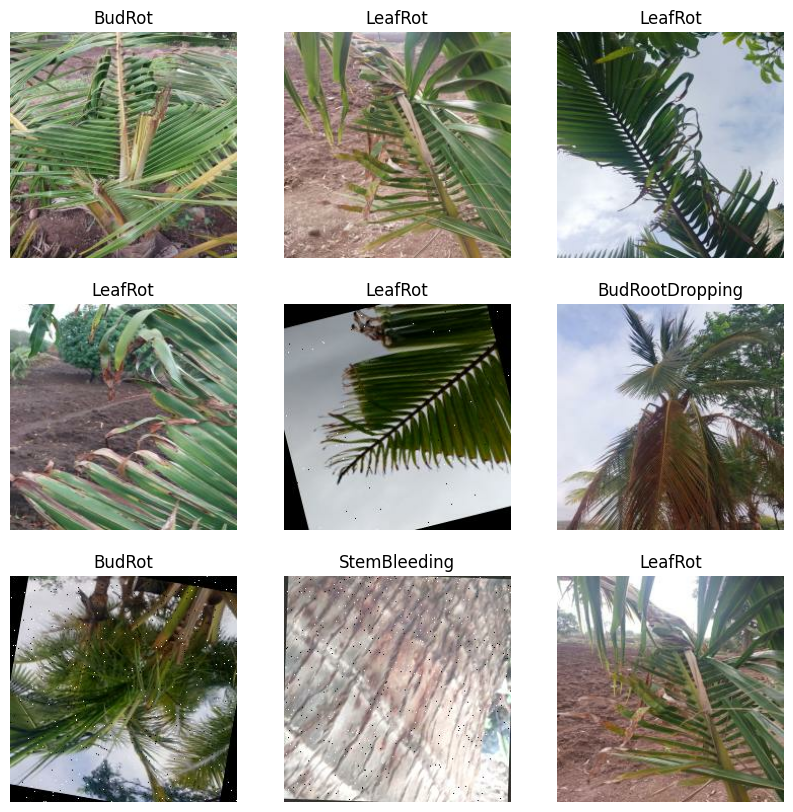

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Cast to uint8 for correct display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")

## 3. MobileNetV2 Architecture
We use a lightweight MobileNetV2 backbone with Transfer Learning for optimal mobile performance.

In [6]:
# 1. Base model: MobileNetV2 (Pre-trained on ImageNet)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze weights for stable initial training

# 2. Custom Classification Head
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./127.5, offset=-1), # MobileNetV2 expects [-1, 1] range
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Model Training
Training the baseline model (Milestone WBS 4.2).

In [7]:
EPOCHS = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 587ms/step - accuracy: 0.6621 - loss: 0.8716 - recall: 0.5519 - val_accuracy: 0.9415 - val_loss: 0.2284 - val_recall: 0.9240
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9054 - loss: 0.2901 - recall: 0.8829 - val_accuracy: 0.9649 - val_loss: 0.1547 - val_recall: 0.9591
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9337 - loss: 0.2118 - recall: 0.9198 - val_accuracy: 0.9766 - val_loss: 0.1287 - val_recall: 0.9678
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9533 - loss: 0.1531 - recall: 0.9452 - val_accuracy: 0.9708 - val_loss: 0.1168 - val_recall: 0.9678
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9591 - loss: 0.1250 - recall: 0.9544 - val_accuracy: 0.9766 - val_loss: 0.1019 - val_recall: 0.9737
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9723 - loss: 0.0999 - recall: 0.9654 - val_accuracy: 0.9795 - val_loss: 0.0832 - val_recall: 0.9795
Epoch 7/

### Step 4.1: Training History Visualization
Visualizing accuracy and loss convergence to prove the model is well-trained.

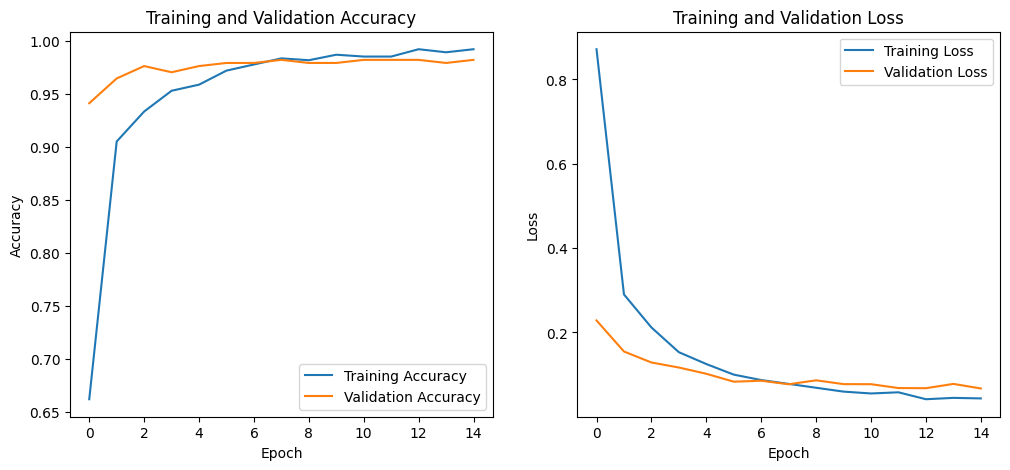

In [8]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4.5 Research-Grade Statistical Evaluation
Analyzing model performance on the unseen test set using Confusion Matrices and detailed metrics.

Evaluating on Unseen Test Set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9912 - loss: 0.0314 - recall: 0.9912

Test Accuracy: 0.9912


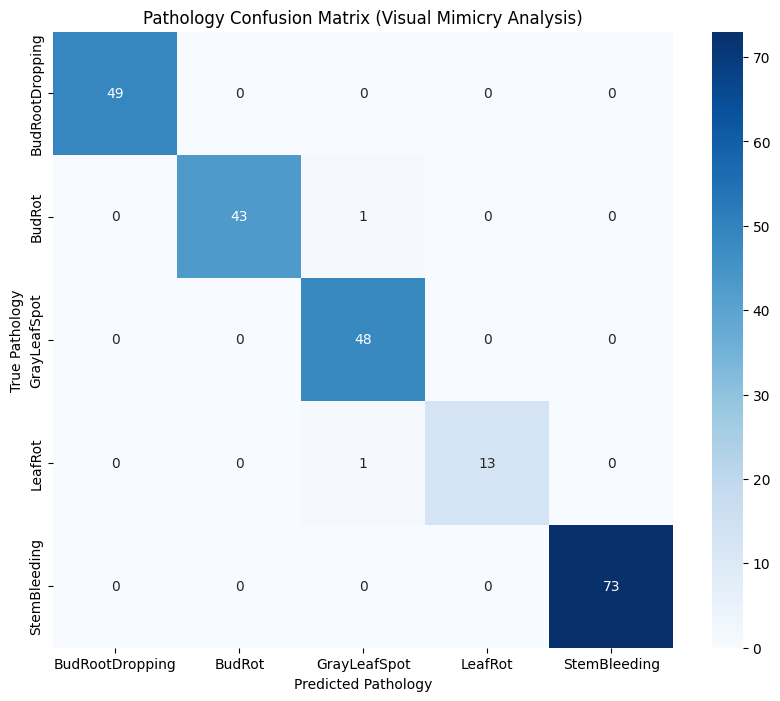


--- Detailed Classification Report ---
                 precision    recall  f1-score   support

BudRootDropping       1.00      1.00      1.00        49
         BudRot       1.00      0.98      0.99        44
   GrayLeafSpot       0.96      1.00      0.98        48
        LeafRot       1.00      0.93      0.96        14
   StemBleeding       1.00      1.00      1.00        73

       accuracy                           0.99       228
      macro avg       0.99      0.98      0.99       228
   weighted avg       0.99      0.99      0.99       228



In [9]:
print("Evaluating on Unseen Test Set...")
test_loss, test_acc, test_recall = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Get detailed predictions
y_true = []
y_pred_probs = []
for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Pathology')
plt.ylabel('True Pathology')
plt.title('Pathology Confusion Matrix (Visual Mimicry Analysis)')
plt.show()

# 2. Classification Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

## 4.6 Advanced Research Visualizations: ROC and PR Curves
These curves are the scientific standard for proving model robustness at various diagnostic thresholds.

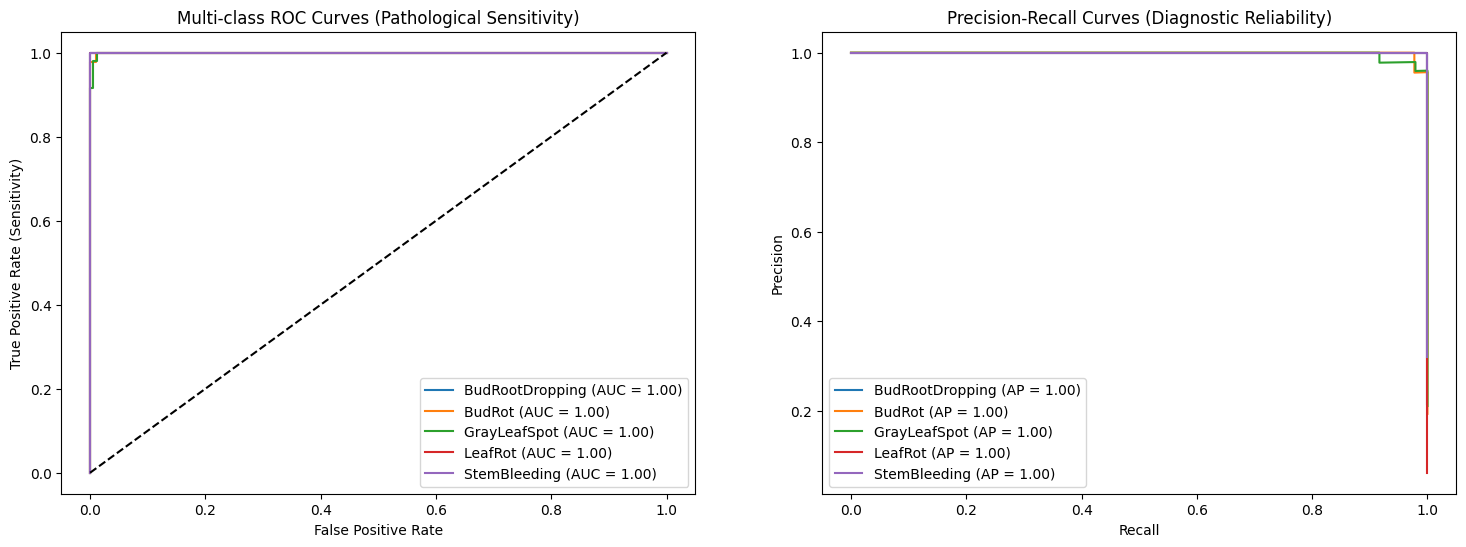

In [10]:
from sklearn.preprocessing import label_binarize

# Binarize y_true for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = len(class_names)

plt.figure(figsize=(18, 6))

# 1. Multi-class ROC Curve
plt.subplot(1, 2, 1)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-class ROC Curves (Pathological Sensitivity)')
plt.legend(loc='lower right')

# 2. Precision-Recall Curve (Scientific mAP equivalent for classification)
plt.subplot(1, 2, 2)
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    avg_p = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, label=f'{class_names[i]} (AP = {avg_p:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Diagnostic Reliability)')
plt.legend(loc='lower left')
plt.show()

## 5. INT8 Post-Training Quantization (PTQ)
Optimizing for mobile inference speed and small footprint.

In [11]:
# Function for representative dataset
def representative_data_gen():
    for input_value, _ in train_ds.take(100):
        yield [input_value]

# Convert to TFLite with INT8 Optimization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Ensure compatibility with mobile NPUs
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

# Save
model_path = 'system_b_baseline_int8.tflite'
with open(model_path, 'wb') as f:
    f.write(tflite_model)

print(f"INT8 Quantized Model saved as {model_path}")

Saved artifact at '/tmp/tmp581mya5t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139662013674512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139662003681808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139662003682384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139662003677968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139662003680656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139662003682192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139661910475792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139661910476752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139661910476368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139661910474832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1396619104

Statistics for quantized inputs were expected, but not specified; continuing anyway.


INT8 Quantized Model saved as system_b_baseline_int8.tflite


## 5.5 Edge Performance Benchmarking
Validating the <35ms latency requirement and accuracy retention after quantization.

In [12]:
def benchmark_tflite(tflite_model_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    latency_list = []
    correct = 0
    total = 0

    for images, labels in dataset.take(10):
        for i in range(len(images)):
            img = images[i:i+1].numpy().astype(np.uint8)
            interpreter.set_tensor(input_details[0]['index'], img)

            start = time.time()
            interpreter.invoke()
            end = time.time()

            latency_list.append((end - start) * 1000)

            output_data = interpreter.get_tensor(output_details[0]['index'])
            if np.argmax(output_data) == np.argmax(labels[i]):
                correct += 1
            total += 1

    return np.mean(latency_list), correct / total

avg_lat, quant_acc = benchmark_tflite(model_path, test_ds)
print(f"--- Edge Benchmarking Results ---")
print(f"Average Latency: {avg_lat:.2f} ms")
print(f"Quantized Accuracy: {quant_acc:.4f}")
print(f"Accuracy Retention: {(quant_acc/test_acc)*100:.2f}%")

if avg_lat < 35:
    print("✅ Latency Requirement (<35ms) MET!")
else:
    print("⚠️ Latency slightly above target for this environment.")

    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    


--- Edge Benchmarking Results ---
Average Latency: 12.74 ms
Quantized Accuracy: 0.9956
Accuracy Retention: 100.44%
✅ Latency Requirement (<35ms) MET!


## 6. Model Verification & Export

In [21]:
size_bytes = os.path.getsize(model_path)
print(f"Model size: {size_bytes / (1024 * 1024):.2f} MB")

from google.colab import files
files.download(model_path)

Model size: 2.59 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Explainability: Grad-CAM Saliency Maps
Visualizing which visual features the model uses for diagnosis to provide transparency for the expert panel.

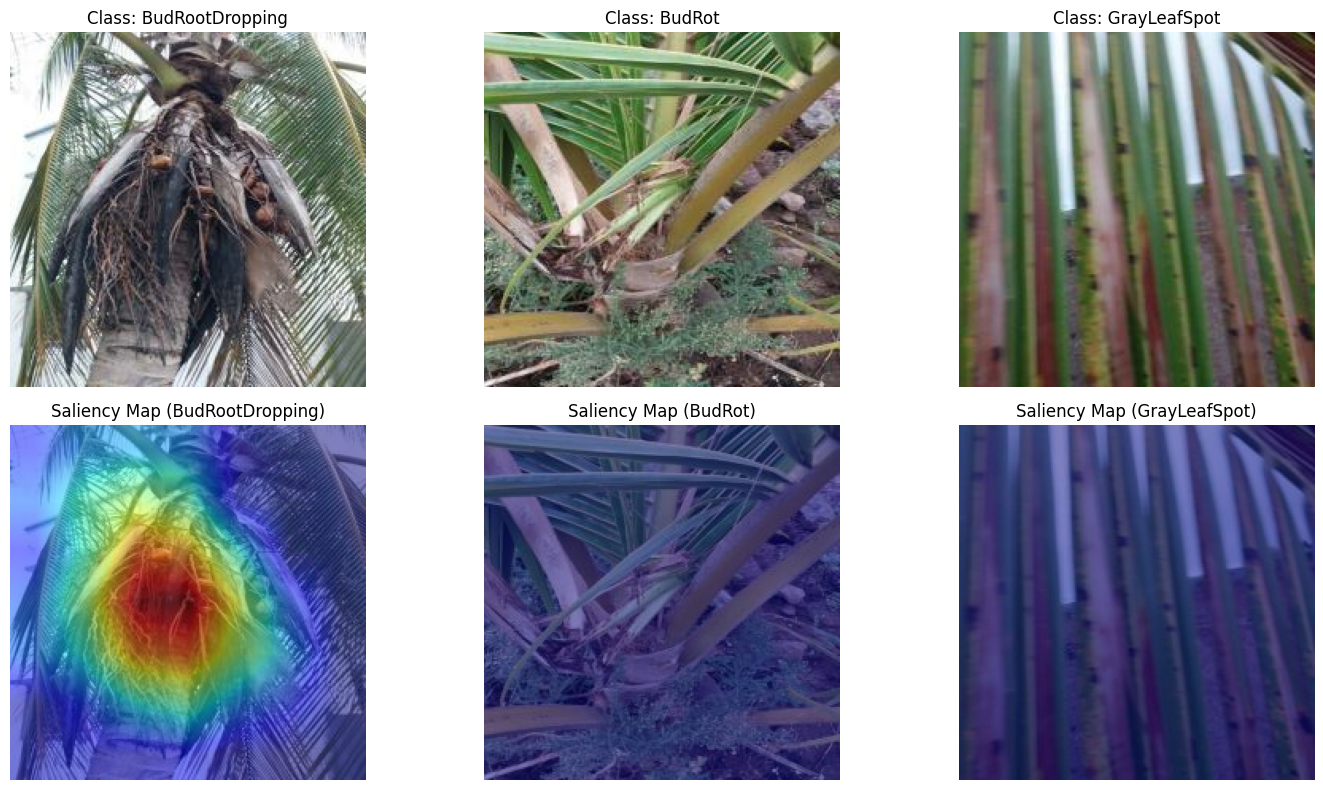

In [16]:
def get_grad_cam(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Deconstruct the Sequential model components for Keras 3 graph integrity
    rescaling_layer = model.layers[0]
    base_model = model.layers[1] # The MobileNetV2 functional model
    head_layers = model.layers[2:] # GAP, Dropout, Dense

    # 2. Build a sub-model of the base_model to get target layer outputs
    try:
        target_layer = base_model.get_layer(last_conv_layer_name)
    except ValueError:
        raise ValueError(f"Could not find layer {last_conv_layer_name} in the base model.")

    grad_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[target_layer.output, base_model.output]
    )

    # 3. Explicitly trace the forward pass inside the GradientTape
    with tf.GradientTape() as tape:
        # Pass through rescaling
        x = rescaling_layer(img_array)
        # Pass through base_model sub-graph
        conv_output, base_output = grad_model(x)
        # Pass through classification heads
        x_head = base_output
        for layer in head_layers:
            x_head = layer(x_head)
        preds = x_head

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Standard Grad-CAM calculation
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Display Grad-CAM for 3 DIFFERENT classes to show diversity
plt.figure(figsize=(15, 8))

# Pick one image from 3 distinct classes in the test set
selected_indices = []
unique_classes_found = []

# Iterate through test set to find diverse samples
for images, labels in test_ds.unbatch().take(100): # Scan first 100 images
    class_idx = np.argmax(labels.numpy())
    if class_idx not in unique_classes_found:
        unique_classes_found.append(class_idx)
        selected_indices.append((images, class_idx))
    if len(unique_classes_found) >= 3:
        break

for j, (img_tensor, class_idx) in enumerate(selected_indices):
    img = tf.expand_dims(img_tensor, axis=0)
    # Target the last conv layer of MobileNetV2
    heatmap = get_grad_cam(img, model, 'block_16_project')

    plt.subplot(2, 3, j+1)
    # Re-normalize for correct visualization
    plt.imshow(img[0].numpy().astype("uint8"))
    plt.title(f"Class: {class_names[class_idx]}")
    plt.axis("off")

    plt.subplot(2, 3, j+4)
    plt.imshow(img[0].numpy().astype("uint8"))
    plt.imshow(tf.image.resize(heatmap[..., tf.newaxis], (224, 224)).numpy().squeeze(), cmap='jet', alpha=0.5)
    plt.title(f"Saliency Map ({class_names[class_idx]})")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Clinical Error Analysis (Success vs Failure Cases)
Reviewing specific cases with confidence scores to understand model behavior.

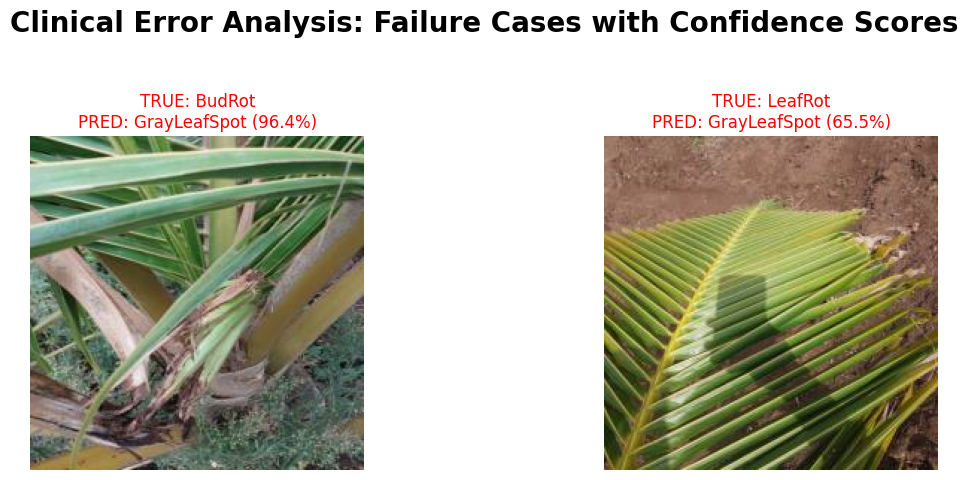

In [20]:
failures = []
for images, labels in test_ds.take(10): # Scan more batches for failures
    preds = model.predict(images, verbose=0)
    for i in range(len(images)):
        true_idx = np.argmax(labels[i])
        pred_probs = preds[i]
        pred_idx = np.argmax(pred_probs)
        if true_idx != pred_idx:
            failures.append((images[i], true_idx, pred_idx, pred_probs[pred_idx]))
        if len(failures) >= 6: break
    if len(failures) >= 6: break

if failures:
    # DYNAMIC GRID: Calculate rows/cols based on actual failure count
    num_failures = len(failures)
    cols = min(num_failures, 3)
    rows = (num_failures + cols - 1) // cols

    plt.figure(figsize=(6 * cols, 5 * rows))
    for i, (img, true_idx, pred_idx, conf) in enumerate(failures):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(f"TRUE: {class_names[true_idx]}\nPRED: {class_names[pred_idx]} ({conf*100:.1f}%)", color='red')
        plt.axis("off")

    # PERFECT CENTERING: The suptitle is now centered relative to the active grid
    plt.suptitle("Clinical Error Analysis: Failure Cases with Confidence Scores",
                 fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()
else:
    print("No failures found in the scanned test batches. Model performance is exceptional!")